# CodiEsp Dataset — Exploratory Data Analysis

This notebook explores the CodiEsp training annotations:
- Annotation volume and label distribution (DIAG vs PROC)
- Top ICD-10 codes by frequency
- Span length distribution
- Text length distribution
- Code co-occurrence patterns

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from src.data_loader import load_annotations, load_code_labels, resolve_tsv

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Auto-detect the correct TSV filenames for whichever CodiEsp version is installed
# v4 layout: data/train/trainX.tsv  |  older: data/train/codiesp_X_train.tsv
TRAIN_TSV  = resolve_tsv('../data', 'train', task='X')
TRAIN_TEXT = Path('../data/train/text_files/')
DEV_TSV    = resolve_tsv('../data', 'dev',   task='X')

print(f'Train TSV  : {TRAIN_TSV}')
print(f'Train text : {TRAIN_TEXT}')
print(f'Dev   TSV  : {DEV_TSV}')

print('\nLoading annotations...')
df_train = load_code_labels(TRAIN_TSV)
df_dev   = load_code_labels(DEV_TSV)

print(f'Train annotations : {len(df_train):,}')
print(f'Dev   annotations : {len(df_dev):,}')
df_train.head()

Train TSV  : ../data/train/trainX.tsv
Train text : ../data/train/text_files
Dev   TSV  : ../data/dev/devX.tsv

Loading annotations...
Train annotations : 9,181
Dev   annotations : 4,477


,article_id,label,icd10_code,text_reference,ref_start,ref_end
0,S0004-06142005000700014-1,PROCEDIMIENTO,bw03zzz,Rx tórax,2163,2171
1,S0004-06142005000700014-1,PROCEDIMIENTO,3e02329,Estreptomicina intramuscular,-1,-1
2,S0004-06142005000700014-1,DIAGNOSTICO,n44.8,teste derecho aumentado de tamaño,1343,1376
3,S0004-06142005000700014-1,DIAGNOSTICO,z20.818,exposición a Brucella,594,615
4,S0004-06142005000700014-1,DIAGNOSTICO,r60.9,edemas,1250,1256


## 1. Label Distribution (DIAGNOSTICO vs PROCEDIMIENTO)

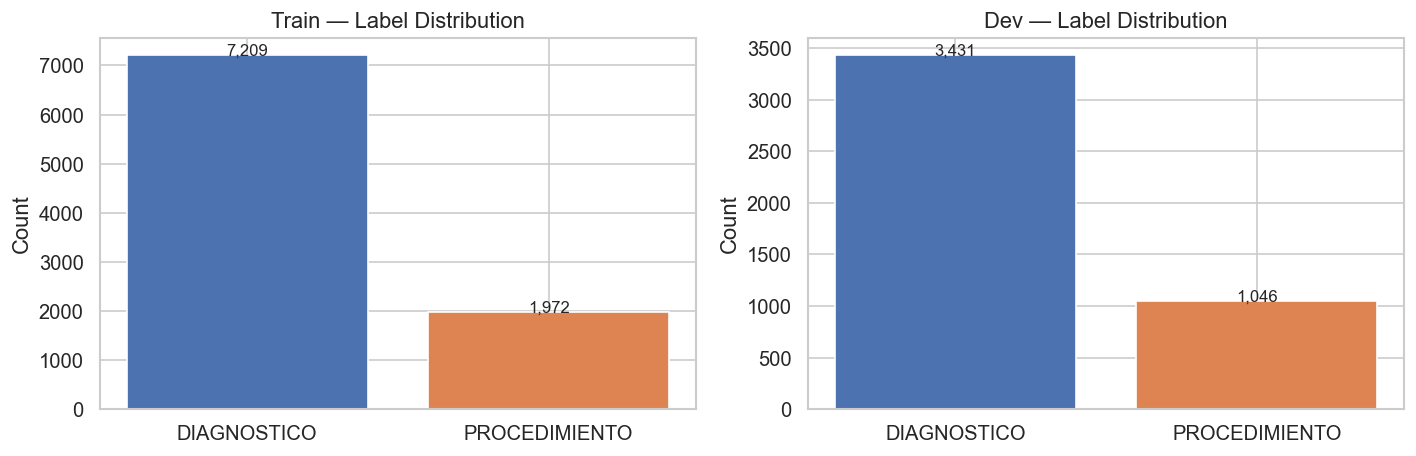

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, title) in zip(axes, [(df_train, 'Train'), (df_dev, 'Dev')]):
    counts = df['label'].value_counts()
    ax.bar(counts.index, counts.values, color=['#4C72B0','#DD8452'])
    ax.set_title(f'{title} — Label Distribution')
    ax.set_ylabel('Count')
    for i, (lbl, val) in enumerate(counts.items()):
        ax.text(i, val + 5, f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/eda_label_dist.png', bbox_inches='tight')
plt.show()

## 2. Annotations per Document

count    500.000000
mean      18.362000
std       11.030426
min        1.000000
25%       11.000000
50%       16.000000
75%       24.000000
max       80.000000
dtype: float64


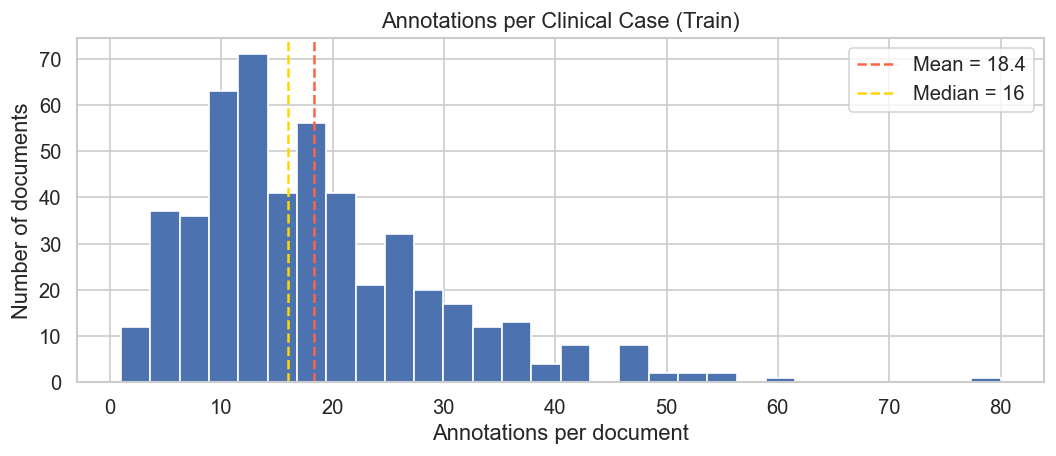

In [3]:
per_doc = df_train.groupby('article_id').size()
print(per_doc.describe())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(per_doc, bins=30, color='#4C72B0', edgecolor='white')
ax.axvline(per_doc.mean(), color='tomato', linestyle='--', label=f'Mean = {per_doc.mean():.1f}')
ax.axvline(per_doc.median(), color='gold', linestyle='--', label=f'Median = {per_doc.median():.0f}')
ax.set_xlabel('Annotations per document')
ax.set_ylabel('Number of documents')
ax.set_title('Annotations per Clinical Case (Train)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/eda_anns_per_doc.png', bbox_inches='tight')
plt.show()

## 3. Top-20 Most Frequent ICD-10 Codes

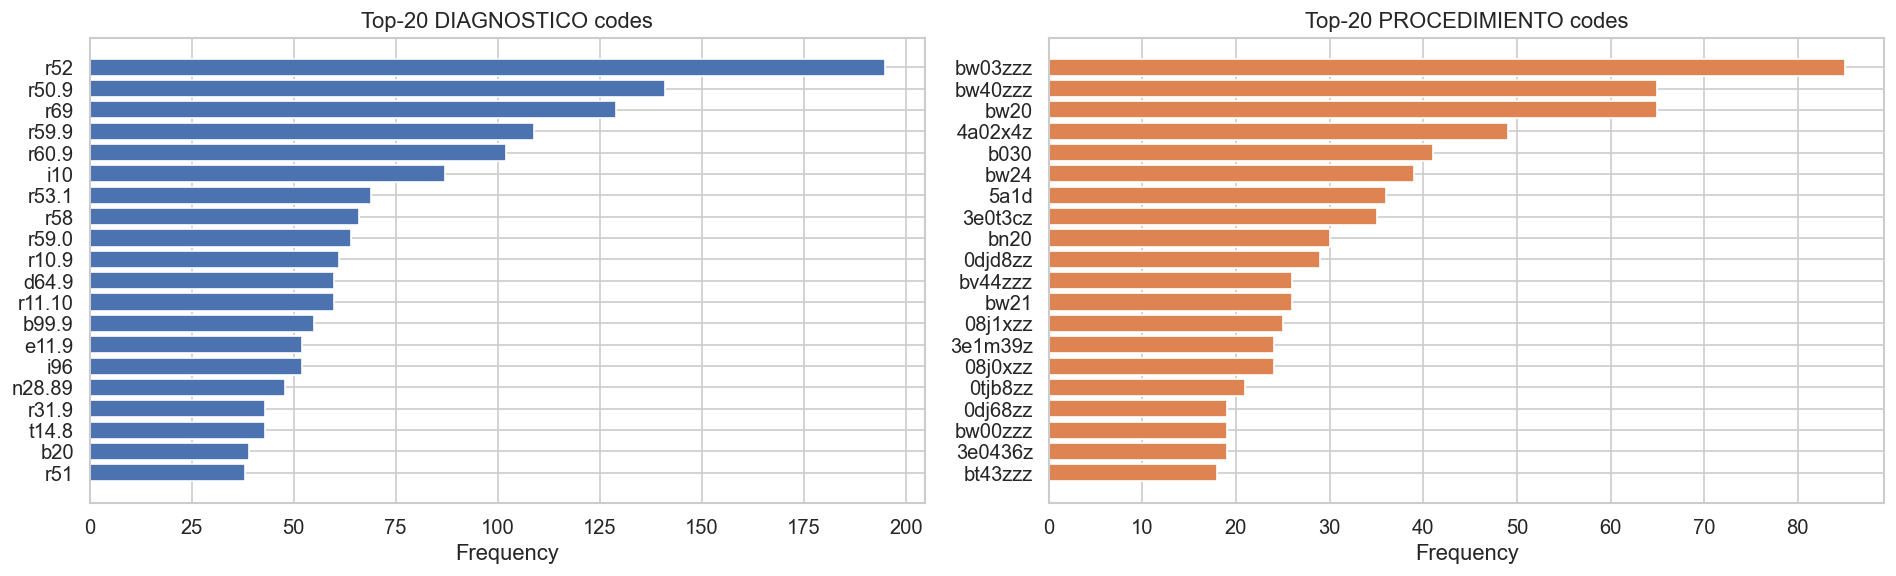

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, color in zip(axes, ['DIAGNOSTICO', 'PROCEDIMIENTO'], ['#4C72B0','#DD8452']):
    top_codes = (
        df_train[df_train['label'] == label]['icd10_code']
        .value_counts()
        .head(20)
    )
    ax.barh(top_codes.index[::-1], top_codes.values[::-1], color=color)
    ax.set_xlabel('Frequency')
    ax.set_title(f'Top-20 {label} codes')

plt.tight_layout()
plt.savefig('../outputs/eda_top_codes.png', bbox_inches='tight')
plt.show()

## 4. Span (text_reference) Length Distribution

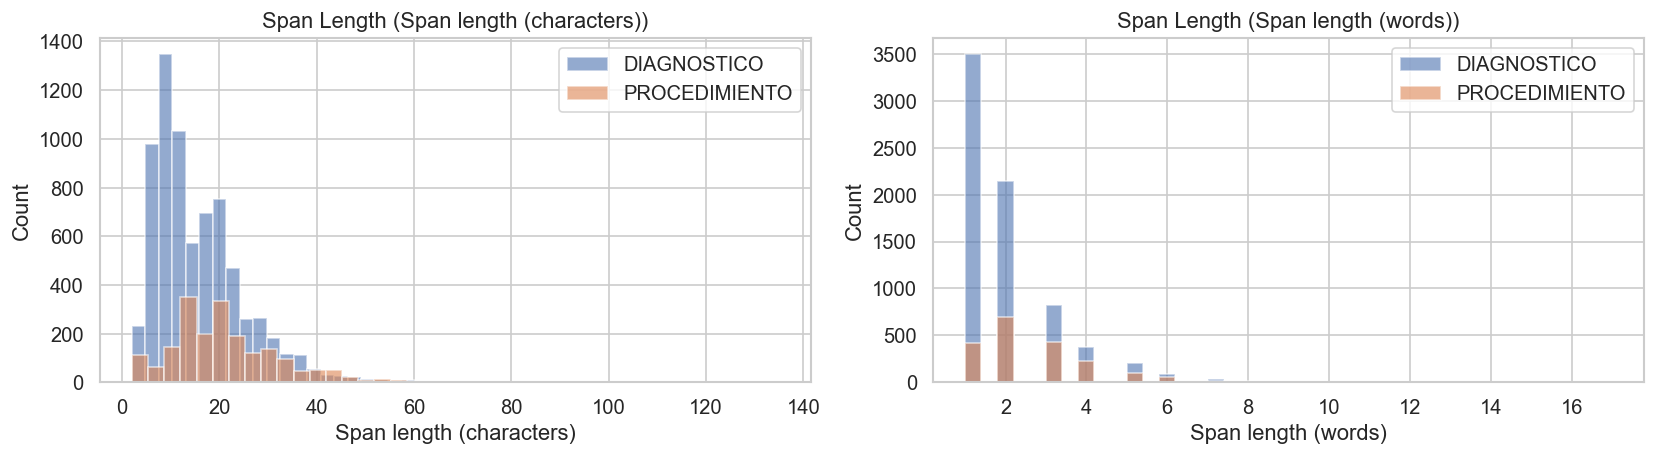

label                 DIAGNOSTICO  PROCEDIMIENTO
span_len_chars count  7209.000000    1972.000000
               mean     15.789430      21.388945
               std       9.478906      12.022148
               min       2.000000       2.000000
               25%       9.000000      13.000000
               50%      14.000000      19.000000
               75%      21.000000      27.000000
               max     113.000000     135.000000
span_len_words count  7209.000000    1972.000000
               mean      1.921626       2.652637
               std       1.256543       1.583312
               min       1.000000       1.000000
               25%       1.000000       2.000000
               50%       2.000000       2.000000
               75%       2.000000       3.000000
               max      17.000000      17.000000


In [5]:
df_train['span_len_chars'] = df_train['text_reference'].str.len()
df_train['span_len_words'] = df_train['text_reference'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, xlabel in zip(
    axes,
    ['span_len_chars', 'span_len_words'],
    ['Span length (characters)', 'Span length (words)']
):
    for label, color in [('DIAGNOSTICO','#4C72B0'), ('PROCEDIMIENTO','#DD8452')]:
        subset = df_train[df_train['label'] == label][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, label=label, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()
    ax.set_title(f'Span Length ({xlabel})')

plt.tight_layout()
plt.savefig('../outputs/eda_span_len.png', bbox_inches='tight')
plt.show()

print(df_train.groupby('label')[['span_len_chars','span_len_words']].describe().T)

## 5. Clinical Text Length Distribution

count     500.000000
mean      349.018000
std       164.745999
min        73.000000
25%       224.750000
50%       314.500000
75%       435.250000
max      1172.000000
Name: word_count, dtype: float64


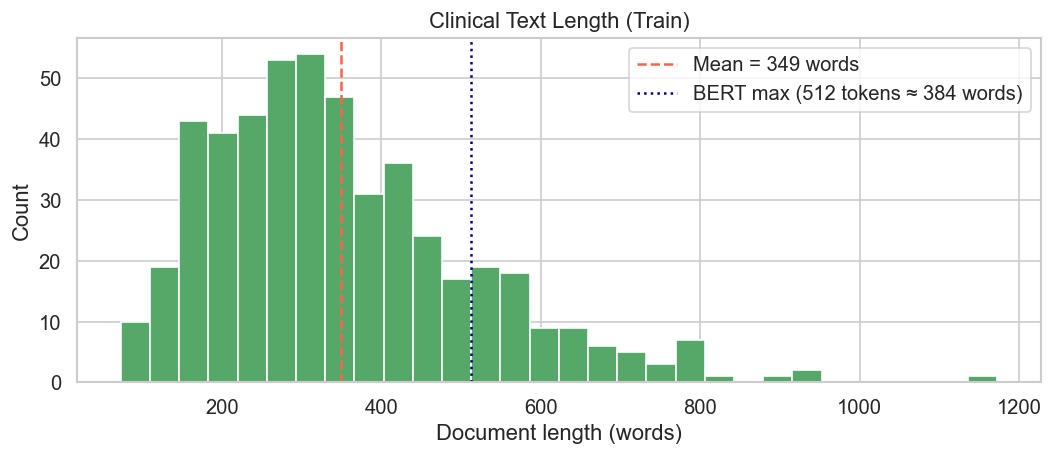


34.8% of documents likely exceed BERT's token limit → sliding window needed


In [6]:
txt_lengths = {}

for txt_file in TRAIN_TEXT.glob('*.txt'):
    text = txt_file.read_text(encoding='utf-8')
    txt_lengths[txt_file.stem] = len(text.split())

lengths = pd.Series(txt_lengths, name='word_count')
print(lengths.describe())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=30, color='#55A868', edgecolor='white')
ax.axvline(lengths.mean(), color='tomato', linestyle='--', label=f'Mean = {lengths.mean():.0f} words')
ax.axvline(512, color='navy', linestyle=':', label='BERT max (512 tokens ≈ 384 words)')
ax.set_xlabel('Document length (words)')
ax.set_ylabel('Count')
ax.set_title('Clinical Text Length (Train)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/eda_text_len.png', bbox_inches='tight')
plt.show()

pct_over_512 = (lengths > 384).mean() * 100
print(f"\n{pct_over_512:.1f}% of documents likely exceed BERT's token limit → sliding window needed")

## 6. Code Frequency — Long Tail Analysis

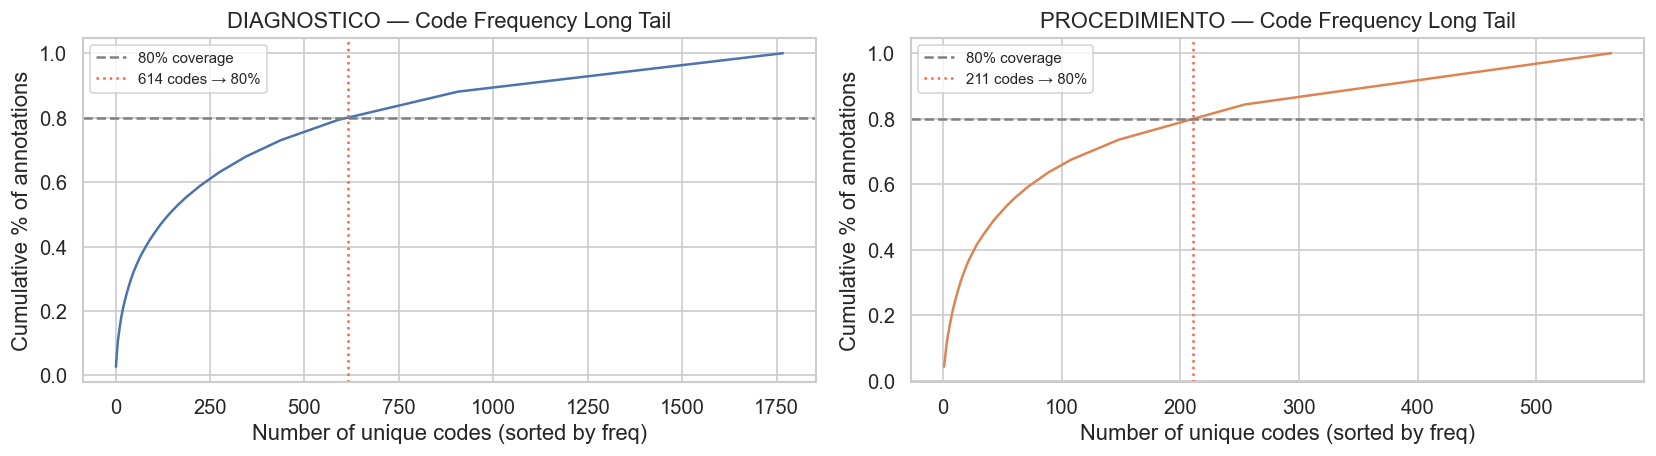

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label, color in zip(axes, ['DIAGNOSTICO', 'PROCEDIMIENTO'], ['#4C72B0','#DD8452']):
    code_freq = df_train[df_train['label'] == label]['icd10_code'].value_counts()
    cumsum = code_freq.cumsum() / code_freq.sum()
    ax.plot(range(1, len(cumsum)+1), cumsum.values, color=color)
    ax.axhline(0.8, color='gray', linestyle='--', label='80% coverage')
    n_for_80 = (cumsum <= 0.8).sum()
    ax.axvline(n_for_80, color='tomato', linestyle=':', label=f'{n_for_80} codes → 80%')
    ax.set_xlabel('Number of unique codes (sorted by freq)')
    ax.set_ylabel('Cumulative % of annotations')
    ax.set_title(f'{label} — Code Frequency Long Tail')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/eda_code_longtail.png', bbox_inches='tight')
plt.show()

## 7. Sample Annotations — Span Preview

In [8]:
from src.data_loader import load_annotations, load_text

anns = load_annotations(TRAIN_TSV)
sample_article = anns[0].article_id
# load_text accepts either text_files/ dir or the split root dir
text = load_text(TRAIN_TEXT, sample_article)

print(f'Article: {sample_article}')
print(f'Text length: {len(text)} chars\n')
print('=== First 500 chars ===')
print(text[:500])
print()
print('=== Annotations ===')
sample_anns = [a for a in anns if a.article_id == sample_article]
for a in sample_anns:
    snippet = text[max(0,a.ref_start-10):a.ref_end+10]
    print(f'  [{a.label}] {a.icd10_code} | "{a.text_reference}" @ {a.ref_start}-{a.ref_end}')
    print(f'    context: "...{snippet}..."')

Article: S0004-06142005000700014-1
Text length: 3108 chars

=== First 500 chars ===
Describimos el caso de un varón de 37 años con vida previa activa que refiere dolores osteoarticulares de localización variable en el último mes y fiebre en la última semana con picos (matutino y vespertino) de 40 C las últimas 24-48 horas, por lo que acude al Servicio de Urgencias. Antes de comenzar el cuadro estuvo en Extremadura en una región endémica de brucella, ingiriendo leche de cabra sin pasteurizar y queso de dicho ganado. Entre los comensales aparecieron varios casos de brucelosis. Du

=== Annotations ===
  [PROCEDIMIENTO] bw03zzz | "Rx tórax" @ 2163-2171
    context: "...citadas ( Rx tórax, Ecografí..."
  [PROCEDIMIENTO] 3e02329 | "Estreptomicina intramuscular" @ -1--1
    context: "...Describim..."
  [DIAGNOSTICO] n44.8 | "teste derecho aumentado de tamaño" @ 1343-1376
    context: "...precia el teste derecho aumentado de tamaño, no adher..."
  [DIAGNOSTICO] z20.818 | "exposición a Brucella

## 8. BIO Label Class Imbalance

In [9]:
# Estimate O vs B/I token ratio from a subset of documents
# This is important for choosing class weights during NER training
from transformers import AutoTokenizer
from src.data_loader import build_bio_examples, LABEL2ID, ID2LABEL
import collections

tokenizer = AutoTokenizer.from_pretrained('PlanTL-GOB-ES/bsc-bio-ehr-es')

# Use first 50 articles for speed
unique_ids = list(dict.fromkeys(a.article_id for a in anns))[:50]
sample_anns = [a for a in anns if a.article_id in unique_ids]
examples = build_bio_examples(str(TRAIN_TEXT), sample_anns, tokenizer, max_length=512, stride=128)

label_counts = collections.Counter()
for ex in examples:
    for lbl in ex['labels']:
        if lbl != -100:
            label_counts[ID2LABEL[lbl]] += 1

total = sum(label_counts.values())
print(f'Token label distribution (sample of 50 docs):')
print(f'{"Label":<12} {"Count":>10} {"Pct":>8}')
for lbl, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f'{lbl:<12} {cnt:>10,} {cnt/total*100:>7.2f}%')

print(f'\n→ Imbalance ratio O vs non-O: {label_counts["O"] / (total - label_counts["O"]):.1f}:1')
print('→ Use class_weight or focal loss during NER training!')

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Token label distribution (sample of 50 docs):
Label             Count      Pct
O                21,619   92.14%
I-DIAG              769    3.28%
B-DIAG              532    2.27%
I-PROC              379    1.62%
B-PROC              163    0.69%

→ Imbalance ratio O vs non-O: 11.7:1
→ Use class_weight or focal loss during NER training!
